# Assignment Part 4 – Data Visualization & Machine Learning

This notebook covers:
- Data exploration
- Data visualization
- Machine learning

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv("students.csv")

# Show first 5 rows
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [3]:
# Basic information about dataset

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

print("\nData Types:\n", df.dtypes)

# Summary statistics
df.describe()

Shape: (15, 9)
Columns: ['name', 'math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day', 'passed']

Data Types:
 name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,65.000000,66.733333,66.200000,63.400000,74.800000,75.800000,2.893333,0.600000
std,20.060622,18.967893,17.773174,16.936014,16.657045,14.722189,1.658944,0.507093
min,30.000000,35.000000,40.000000,28.000000,45.000000,50.000000,0.500000,0.000000
25%,51.500000,53.500000,49.000000,53.500000,61.000000,63.500000,1.650000,0.000000
50%,65.000000,65.000000,70.000000,62.000000,75.000000,78.000000,2.800000,1.000000
75%,80.000000,77.000000,81.000000,73.500000,89.000000,86.500000,3.900000,1.000000
max,95.000000,98.000000,91.000000,92.000000,97.000000,98.000000,6.000000,1.000000


In [4]:
# Calculate average score

subjects = ["math", "science", "english", "history", "pe"]

df["avg_score"] = df[subjects].mean(axis=1)

# Pass vs fail count
print(df["passed"].value_counts())

# Highest scoring student
df.loc[df["avg_score"].idxmax()]

passed
1    9
0    6
Name: count, dtype: int64


name                   Diana
math                      95
science                   98
english                   91
history                   89
pe                        97
attendance_pct            98
study_hours_per_day      6.0
passed                     1
avg_score               94.0
Name: 3, dtype: object

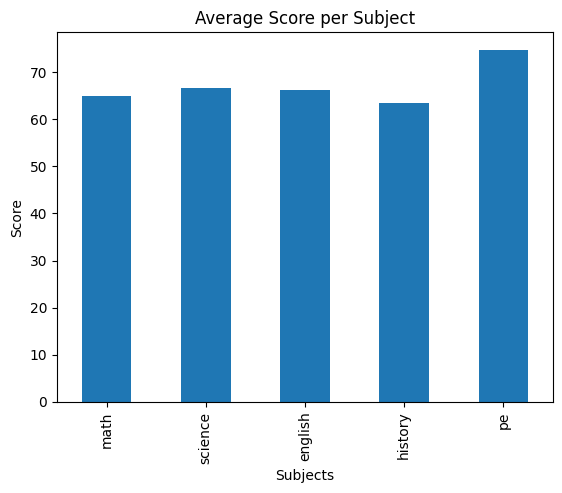

In [5]:
## TASK 2
# Plot 1: Average score per subject (Bar Chart)

subjects = ["math", "science", "english", "history", "pe"]
avg_scores = df[subjects].mean()

avg_scores.plot(kind="bar")

plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Score")

plt.savefig("plot1_bar.png")
plt.show()

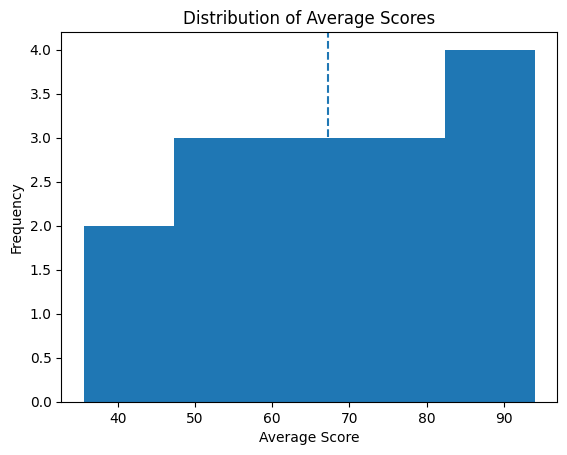

In [6]:
# Plot 2: Distribution of average scores

plt.hist(df["avg_score"], bins=5)

plt.axvline(df["avg_score"].mean(), linestyle="--")

plt.title("Distribution of Average Scores")
plt.xlabel("Average Score")
plt.ylabel("Frequency")

plt.savefig("plot2_hist.png")
plt.show()

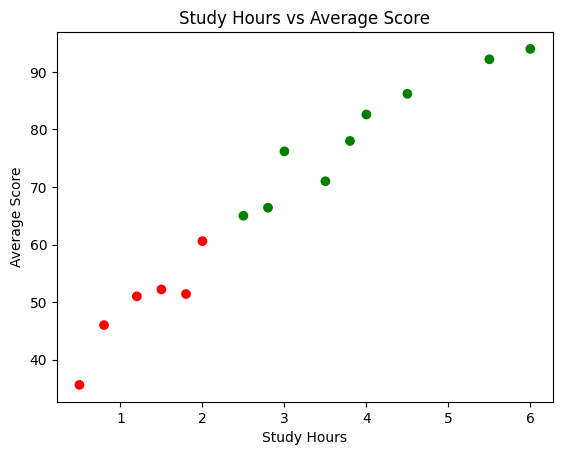

In [7]:
# Plot 3: Study hours vs average score

colors = df["passed"].map({1: "green", 0: "red"})

plt.scatter(df["study_hours_per_day"], df["avg_score"], c=colors)

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours")
plt.ylabel("Average Score")

plt.savefig("plot3_scatter.png")
plt.show()

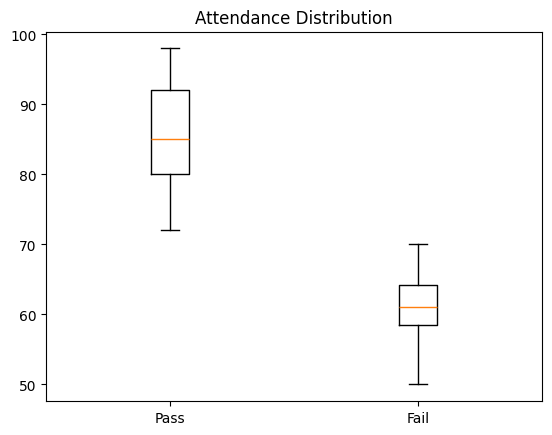

In [8]:
# Plot 4: Attendance comparison (Pass vs Fail)

plt.boxplot([
    df[df["passed"] == 1]["attendance_pct"],
    df[df["passed"] == 0]["attendance_pct"]
])

plt.xticks([1, 2], ["Pass", "Fail"])

plt.title("Attendance Distribution")

plt.savefig("plot4_box.png")
plt.show()

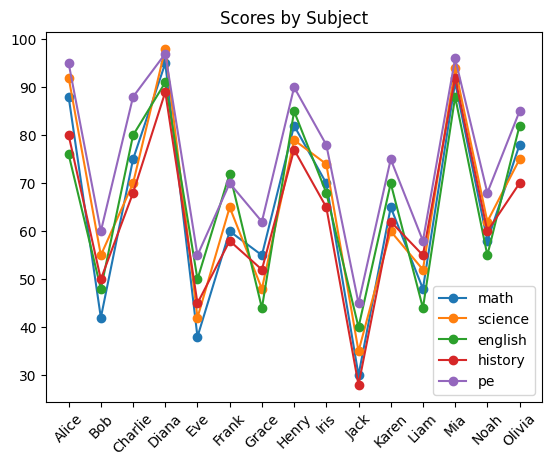

In [9]:
# Plot 5: Scores across subjects for each student

for sub in subjects:
    plt.plot(df["name"], df[sub], marker="o", label=sub)

plt.xticks(rotation=45)
plt.legend()

plt.title("Scores by Subject")

plt.savefig("plot5_line.png")
plt.show()

## Interpretation of Plot 5
This plot shows the performance of each student across different subjects.

We can observe that:
- High-performing students like Diana and Mia score consistently high across all subjects.
- Some students like Bob and Eve have lower scores across subjects.
- There is variation in subject performance, but strong students perform well in most subjects.

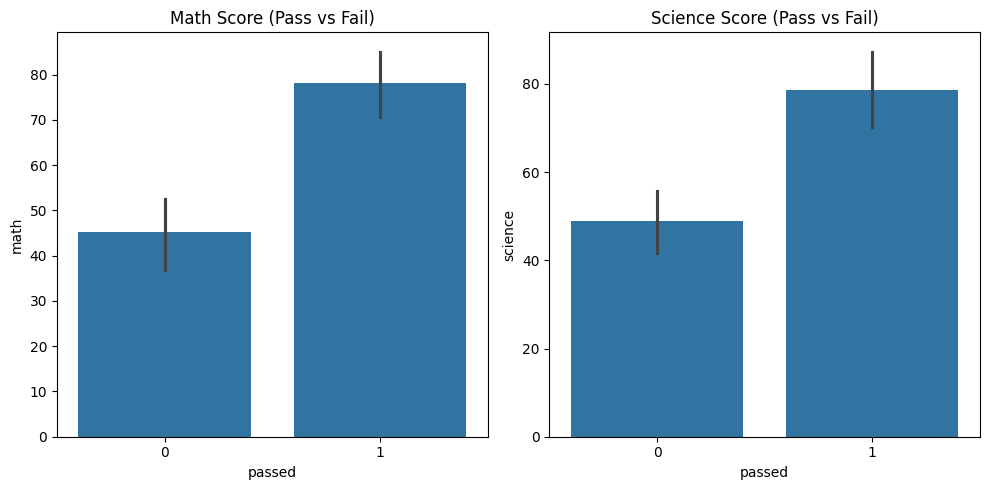

In [10]:
## TASK 3
# Plot 6: Seaborn Bar Plot (Math & Science - Pass vs Fail)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

# Subplot 1: Math
plt.subplot(1,2,1)
sns.barplot(data=df, x="passed", y="math")
plt.title("Math Score (Pass vs Fail)")

# Subplot 2: Science
plt.subplot(1,2,2)
sns.barplot(data=df, x="passed", y="science")
plt.title("Science Score (Pass vs Fail)")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()

### Interpretation of Seaborn Bar Plot 6

This plot compares average scores across subjects for students who passed and failed.

We can observe that:
- Students who passed have significantly higher average scores in all subjects.
- The difference between pass and fail groups is consistent across subjects.
- Physical Education (PE) shows the highest average scores for both groups.

## Seaborn vs Matplotlib
Seaborn was easier to use for creating visually appealing plots with less code, especially for grouped data and styling. 
Matplotlib required more manual customization for labels, colors, and layout. 
Overall, Seaborn simplifies data visualization while Matplotlib provides more control.

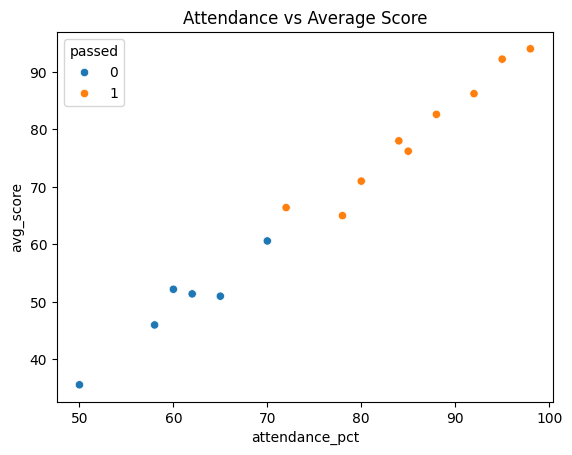

In [11]:
# Plot 7: Seaborn Scatter Plot

sns.scatterplot(
    data=df,
    x="attendance_pct",
    y="avg_score",
    hue="passed"
)

plt.title("Attendance vs Average Score")
plt.savefig("plot7_seaborn_scatter.png")
plt.show()

Seaborn plots are easier to use and provide better default styling compared to Matplotlib.

# TASK 4 : MACHINE LEARNING

In [12]:
# Select features and target

features = ["math", "science", "english", "history", "pe", "attendance_pct", "study_hours_per_day"]
X = df[features]
y = df["passed"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

test_indices = X_test.index

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [16]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

# Accuracy
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 1.0


In [17]:
names = df.loc[test_indices, "name"]

for name, actual, pred in zip(names, y_test, y_pred):
    result = "✅ Correct" if actual == pred else "❌ Wrong"
    print(f"{name}: Actual={actual}, Predicted={pred} → {result}")

Jack: Actual=0, Predicted=0 → ✅ Correct
Liam: Actual=0, Predicted=0 → ✅ Correct
Alice: Actual=1, Predicted=1 → ✅ Correct


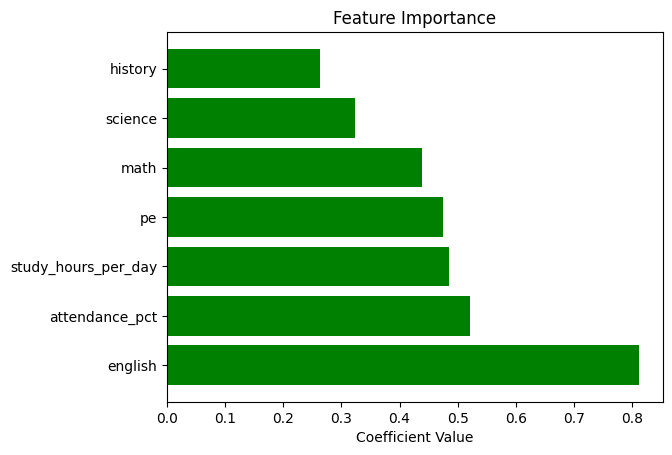

In [18]:
import matplotlib.pyplot as plt
import numpy as np

coefficients = model.coef_[0]

# Sort by absolute value
indices = np.argsort(np.abs(coefficients))[::-1]

sorted_features = [features[i] for i in indices]
sorted_coeff = coefficients[indices]

# Colors
colors = ["green" if c > 0 else "red" for c in sorted_coeff]

plt.barh(sorted_features, sorted_coeff, color=colors)
plt.title("Feature Importance")
plt.xlabel("Coefficient Value")

plt.savefig("plot8_feature_importance.png")
plt.show()

In [19]:
import pandas as pd

new_student = pd.DataFrame(
    [[75, 70, 68, 65, 80, 82, 3.2]],
    columns=features
)

# Scale
new_student_scaled = scaler.transform(new_student)

# Predict
prediction = model.predict(new_student_scaled)[0]
probability = model.predict_proba(new_student_scaled)

print("Prediction:", "Pass" if prediction == 1 else "Fail")
print("Probability:", probability)

Prediction: Pass
Probability: [[0.09203526 0.90796474]]
